# 001 LangGraph Overview

这是 LangGraph 学习线的第一份 Notebook。

官方参考：

- https://docs.langchain.com/oss/python/langgraph/overview

学习目标：

1. 理解 LangGraph 是低层 orchestration runtime
2. 区分 state、node、edge、graph、compiled graph
3. 跑通 `StateGraph(MessagesState)` 最小示例
4. 跑通自定义 `TypedDict` state 示例
5. 对比 LangGraph workflow、本仓库 Harness Query Loop、LangChain agent

这一讲不调用真实模型，先用普通 Python 节点建立 LangGraph 的基本心智模型。

## 1. LangGraph 是什么

可以先把 LangGraph 理解成：

```text
用于构建长运行、有状态、可恢复 agent/workflow 的低层编排框架。
```

它和 LangChain agent 的关系大概是：

```text
LangChain agent：更高层，快速创建 agent。
LangGraph：更底层，自己定义状态、节点、边和控制流。
```

如果用 Java 类比：

```text
LangChain agent 更像开箱即用的 Service。
LangGraph 更像你自己定义 Workflow Engine 的步骤和状态流转。
```

## 2. 五个核心概念

| 概念 | 含义 |
| --- | --- |
| state | 图运行时携带的数据 |
| node | 处理 state 的一个步骤 |
| edge | 从一个 node 到另一个 node 的连接 |
| graph | 节点和边组成的流程定义 |
| compiled graph | 编译后可以 `invoke` / `stream` 的可运行对象 |

最小心智模型：

```text
state 进入 node
node 返回 state update
edge 决定下一个 node
直到 END
```

In [7]:
import importlib.metadata

print("langgraph", importlib.metadata.version("langgraph"))
print("langchain", importlib.metadata.version("langchain"))

langgraph 1.2.1
langchain 1.3.1


## 3. 第一个图：MessagesState

`MessagesState` 是 LangGraph 里常用的消息状态。

它适合聊天或 agent 场景，因为 state 里天然有：

```text
messages
```

下面的图只有一个节点：

```text
START -> mock_llm -> END
```

`mock_llm` 不调用真实模型，只根据用户最后一条消息返回一条 AI 消息。

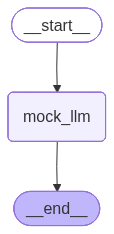

In [8]:
from langgraph.graph import END, START, MessagesState, StateGraph


def mock_llm(state: MessagesState) -> dict:
    last_message = state["messages"][-1]
    content = getattr(last_message, "content", str(last_message))
    return {
        "messages": [
            {
                "role": "ai",
                "content": "我收到了你的消息：" + content,
            }
        ]
    }


message_graph_builder = StateGraph(MessagesState)
message_graph_builder.add_node("mock_llm", mock_llm)
message_graph_builder.add_edge(START, "mock_llm")
message_graph_builder.add_edge("mock_llm", END)

message_graph = message_graph_builder.compile()
message_graph

## 4. 执行第一个图

编译后的 graph 可以直接 `invoke(...)`。

输入是 state：

```python
{"messages": [{"role": "user", "content": "你好"}]}
```

输出也是 state，只是 messages 里追加了 AI 消息。

In [9]:
message_result = message_graph.invoke(
    {"messages": [{"role": "user", "content": "你好，LangGraph"}]}
)

for message in message_result["messages"]:
    print(type(message).__name__, "=>", message.content)

HumanMessage => 你好，LangGraph
AIMessage => 我收到了你的消息：你好，LangGraph


## 5. 自定义 state

`MessagesState` 适合聊天。

但业务 workflow 往往需要自己的字段。

例如：

```text
topic
notes
answer
```

可以用 `TypedDict` 定义 state schema。

In [10]:
from typing import TypedDict


class StudyState(TypedDict):
    topic: str
    notes: list[str]
    answer: str


def collect_notes(state: StudyState) -> dict:
    topic = state["topic"]
    return {
        "notes": [
            topic + " 需要关注 state",
            topic + " 需要关注 node",
            topic + " 需要关注 edge",
        ]
    }


def build_answer(state: StudyState) -> dict:
    lines = ["学习要点："] + ["- " + item for item in state["notes"]]
    return {"answer": "\n".join(lines)}

## 6. 组装自定义 state 图

这个图有两个节点：

```text
START -> collect_notes -> build_answer -> END
```

In [16]:
study_graph_builder = StateGraph(StudyState)
study_graph_builder.add_node("collect_notes", collect_notes)
study_graph_builder.add_node("build_answer", build_answer)

study_graph_builder.add_edge(START, "collect_notes")
study_graph_builder.add_edge("collect_notes", "build_answer")
study_graph_builder.add_edge("build_answer", END)

study_graph = study_graph_builder.compile()

study_result = study_graph.invoke(
    {
        "topic": "LangGraph",
        "notes": [],
        "answer": "",
    }
)

print(study_result["answer"])

学习要点：
- LangGraph 需要关注 state
- LangGraph 需要关注 node
- LangGraph 需要关注 edge


## 7. 和本仓库 Harness 的关系

本仓库 Harness Chat Agent 的核心是 Query Loop：

```text
planner -> action -> tool/delegate/answer -> ledger -> continue or stop
```

LangGraph 的核心是图：

```text
state -> node -> edge -> node -> END
```

两者的共同点：

- 都强调状态
- 都强调可控步骤
- 都需要清晰停止条件
- 都可以支持审批、恢复、验证

差异：

- Harness Query Loop 更像一个通用 agent runtime
- LangGraph 更适合把流程显式画成图

## 8. 本讲练习

请用自己的话回答：

1. LangGraph 里的 state 是什么？
2. node 返回的是完整 state，还是 state update？
3. 为什么 `compile()` 之后才能 `invoke()`？
4. 什么时候应该用 `MessagesState`，什么时候应该自定义 `TypedDict` state？

参考方向：

- state 是运行时携带的数据
- node 通常返回 state update
- compile 会把图定义变成可运行对象
- 聊天用 `MessagesState` 更方便，业务流程用自定义 state 更清晰

## 9. 本讲小结

这一讲的核心：

```text
LangGraph = state + node + edge + compiled graph
```

你现在应该能看懂：

- `StateGraph(...)`
- `add_node(...)`
- `add_edge(...)`
- `START` / `END`
- `compile()`
- `invoke(...)`

下一讲可以继续学习 LangGraph 的 graph API、条件边和 state reducer。